> 🚀 **Colab Notebook:** You can run directly in this:

> [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1msxaUBOXxzJBfKS7OXW6oMfz2PDcuxjJ)

In [ ]:
%%capture
!pip install -U bitsandbytes>=0.46.1
!pip install trl evaluate
!pip install optuna
# update for merge LoRA
!pip install -U torchao

In [ ]:
import os
import argparse
import gc
import torch
import torch.nn.functional as F
from dataclasses import dataclass
from datasets import load_dataset
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    AutoPeftModelForCausalLM
)
from trl import SFTTrainer, SFTConfig

In [ ]:
@dataclass
class Config:
    ver: int = 1
    base_model: str = "mistralai/Mistral-7B-v0.3"
    #instruction_model: str = "mistralai/Mistral-7B-Instruct-v0.3"
    output_dir: str = ""
    input_dir: str = "Edoh/manim_python"

    #trainer config
    max_length: int = 512
    learning_rate: float = 2e-4
    weight_decay: float = 0.03
    per_device_batch: int = 2
    grad_accum_steps: int = 4
    n_epochs: int = 2
    max_grad_norm: float = 0.3
    warmup_steps: float = 0.1

    # lora config
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.05

    seed = 2202

    def __post_init__(self):
        self.output_dir = f"./mistral_ver{self.ver}_code_generation"
        print(f"create folder at: {self.output_dir}")
        os.makedirs(self.output_dir, exist_ok=True)


config = Config()
print(f"model: {config.base_model}")
print(f"input_dir: {config.input_dir}")
print(f"output_dir: {config.output_dir}")
print(f"lora_r: {config.lora_r}")
print(f"lora_alpha: {config.lora_alpha}")
print(f"lora_dropout: {config.lora_dropout}")

create folder at: ./mistral_ver1_code_generation
model: mistralai/Mistral-7B-v0.3
input_dir: Edoh/manim_python
output_dir: ./mistral_ver1_code_generation
lora_r: 16
lora_alpha: 32
lora_dropout: 0.05


In [ ]:
def parse_arg():
    parser = argparse.ArgumentParser(description="CLI train Mistral")
    parser.add_argument("--ver", type=int, default=1)
    parser.add_argument("--base_model", type=str, default="mistralai/Mistral-7B-v0.3")
    parser.add_argument("--max_length", type=int, default=512)
    parser.add_argument("--learning_rate", type=float, default=2e-4)
    parser.add_argument("--output_dir", type=str, default="./mistral_ver1_code_generation")
    parser.add_argument("--input_dir", type=str, default="Edoh/manim_python")
    parser.add_argument("--weight_decay", type=float, default=0.03)
    parser.add_argument("--per_device_batch", type=int, default=2)
    parser.add_argument("--grad_accum_steps", type=int, default=4)
    parser.add_argument("--n_epochs", type=int, default=2)
    parser.add_argument("--max_grad_norm", type=float, default=0.3)
    parser.add_argument("--warmup_steps", type=float, default=0.1)
    # lora config
    parser.add_argument("--lora_r", type=int, default=16)
    parser.add_argument("--lora_alpha", type=int, default=32)
    parser.add_argument("--lora_dropout", type=float, default=0.05)

    # ignore flag in colab.. only use in colab
    args, unknown = parser.parse_known_args()
    return args
    #return parser.parse_args()

args = parse_arg()
config = Config(**vars(args))
config

create folder at: ./mistral_ver1_code_generation


Config(ver=1, base_model='mistralai/Mistral-7B-v0.3', output_dir='./mistral_ver1_code_generation', input_dir='Edoh/manim_python', max_length=512, learning_rate=0.0002, weight_decay=0.03, per_device_batch=2, grad_accum_steps=4, n_epochs=2, max_grad_norm=0.3, warmup_steps=0.1, lora_r=16, lora_alpha=32, lora_dropout=0.05)

In [ ]:
def is_bfloat16_supported():
    """Returns True if the GPU supports bfloat16 (Ampere / RTX 30xx or newer)."""
    if torch.cuda.is_available():
        return True if torch.cuda.get_device_capability()[0] >= 8 else False
    else:
        return True  # MPS (Apple Silicon) and modern CPUs handle bf16

def cleanup(objects=None):
    """Deletes objects and flushes GPU memory."""
    if objects is not None:
        for obj in objects:
            del obj
    torch.cuda.empty_cache()
    gc.collect()

def info_device():
    """Determines and returns the optimal PyTorch device based on hardware availability."""

    print(f"PyTorch version: {torch.__version__}", end=" -- ")

    # Prefer MPS (Metal Performance Shaders) on Apple Silicon Macs
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        print("using MPS device on macOS")
        return torch.device("mps")

    # Fall back to CUDA (NVIDIA GPU) or CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"using {device}")
    return device

device = info_device()
# bfloat16 is preferred on Ampere+ GPUs; float16 is the safe fallback
dtype = torch.bfloat16 if is_bfloat16_supported() else torch.float16
print(f"Using dtype: {dtype}")

PyTorch version: 2.11.0+cu128 -- using cuda
Using dtype: torch.float16


In [ ]:
ds = load_dataset("Edoh/manim_python", split="train")

In [ ]:
# import numpy as np
# #manual split
# def data_split(ds, split=0.8, seed=42):
#     n = len(ds)
#     rng = np.random.default_rng(seed)

#     all_idx = rng.permutation(n)

#     split_point = int(split * n)

#     train_idx = all_idx[:split_point]
#     val_idx = all_idx[split_point:]

#     train_ds = ds.select(train_idx)
#     val_ds = ds.select(val_idx)

#     print(f"Train samples: {len(train_ds)} | Eval samples: {len(val_ds)}")

#     return train_ds, val_ds

# train_ds, val_ds = data_split(ds)
# print("Sample message sequence:", train_ds[0]["instruction"])

In [ ]:
# use train_test_split function from Dataset of Huggingface
def data_split(ds, split=0.8, seed=42):
    split_ds = ds.train_test_split(test_size=0.2, seed=42)
    train_ds = split_ds["train"]
    val_ds = split_ds["test"]
    print(f"Train samples: {len(train_ds)} | Eval samples: {len(val_ds)}")
    print("Sample message sequence:", train_ds[0]["instruction"])
    return train_ds, val_ds
train_ds, val_ds = data_split(ds)

Train samples: 479 | Eval samples: 120
Sample message sequence: Create a point at coordinates (2, 2) and color it blue.


In [ ]:
train_ds[0:3]["instruction"]

['Create a point at coordinates (2, 2) and color it blue.',
 'Create a square with side length 4 and color it blue.',
 'Create a rectangle with width 3 and height 6, centered at (-1, 1).']

In [ ]:
val_ds[:3]["output"]

['from manim import * class MyScene(Scene): def construct(self): pentagon = RegularPolygon(n=5, radius=2, color=ORANGE) self.add(pentagon) self.play(pentagon.animate.rotate(-90 * DEGREES), run_time=2)',
 'from manim import * class MyScene(Scene): def construct(self): rectangle = Rectangle(width=4, height=2) rectangle.move_to((1, 1)) self.add(rectangle)',
 'from manim import * class MyScene(Scene): def construct(self): circle = Circle(radius=2, color=RED) self.add(circle) self.play(circle.animate.shift(RIGHT * 3), run_time=2)']

In [ ]:
def init_tokenizer_and_model(model_name = config.base_model):

    # load tokenizers
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code = True)
    if not tokenizer.pad_token:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"

    # Quantizattion
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",        # Use NF4 (Normal Float 4) quantization type
        bnb_4bit_compute_dtype=torch.float16, # Set compute dtype to bfloat16 for speed
        bnb_4bit_use_double_quant=True,  # Enable nested quantization for more memory saving
        llm_int8_enable_fp32_cpu_offload=False
    )

    # Load the model with quantization configuration
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=quantization_config,
        device_map="auto", # Automatically distribute model layers across available GPUs/CPU
        trust_remote_code=True, # Trust code execution from the model hub (use with caution)
        torch_dtype=torch.float16,
    )
    # verbose
    print(f"Model loaded: {model_name}")
    print(f"Model memory footprint: {model.get_memory_footprint() / 1e9:.2f} GB")

    return model, tokenizer

# lora config
def get_lora(model):

    model = prepare_model_for_kbit_training(model)

    lora_config = LoraConfig(
        r=config.lora_r,
        lora_alpha=config.lora_alpha,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        lora_dropout=config.lora_dropout,
        bias="none",
        task_type="CAUSAL_LM"
    )

    model = get_peft_model(model, lora_config)
    #model = model.to(torch.float16)
    print(f"PEFT model created with LoraConfig: {lora_config}")
    return model

cleanup()
model, tokenizer = init_tokenizer_and_model(config.base_model)
model = get_lora(model)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded: mistralai/Mistral-7B-v0.3
Model memory footprint: 4.03 GB
PEFT model created with LoraConfig: LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.19.1', base_model_name_or_path='mistralai/Mistral-7B-v0.3', revision=None, inference_mode=False, r=16, target_modules={'v_proj', 'k_proj', 'o_proj', 'q_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arr

In [ ]:
print(model)
#print(tokenizer)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MistralForCausalLM(
      (model): MistralModel(
        (embed_tokens): Embedding(32768, 4096)
        (layers): ModuleList(
          (0-31): 32 x MistralDecoderLayer(
            (self_attn): MistralAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_pro

In [ ]:
print(model.base_model.model.lm_head.weight.dtype)

torch.float16


In [ ]:
SYSTEM_PROMPT = """
Yor are an Coding Python Expert, read the instruction and complete these code correctly
"""

#option 1
# Use chat apply template
def formatting_prompts_func(examples):
    instructions = examples.get("instruction", [])
    inputs = examples.get("input", [""] * len(instructions))
    outputs = examples.get("output", [])

    texts = []

    for instr, inp, out in zip(instructions, inputs, outputs):
        user_content = f"{instr}\nInput: {inp}".strip() if (inp and str(inp).strip()) else instr

        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
            {"role": "assistant", "content": out}
        ]

        formatted_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False, # đổi thành false để đưa vào tham số --> dataset_text_field="text"
            add_generation_prompt=False # False khi Training để kèm cả câu trả lời của Assistant
        )
        texts.append(formatted_text)

    return {"text": texts}


# --- Usage ---#
# Option 1 - add chat_template because we are using base model not instruction model :D
tokenizer.chat_template = (
    "{{ bos_token }}"
    "{% for message in messages %}"
        "{% if message['role'] == 'system' %}"
            "{{ 'System: ' + message['content'] + '\n\n' }}"
        "{% elif message['role'] == 'user' %}"
            "{{ '[INST] ' + message['content'] + ' [/INST]' }}"
        "{% elif message['role'] == 'assistant' %}"
            "{{ ' ' + message['content'] + eos_token }}"
        "{% endif %}"
    "{% endfor %}"
)

train_data = train_ds.map(formatting_prompts_func, batched=True)
val_data = val_ds.map(formatting_prompts_func, batched=True)
train_data[0]

{'instruction': 'Create a point at coordinates (2, 2) and color it blue.',
 'output': 'from manim import * class MyScene(Scene): def construct(self): point = Dot((2, 2), color=BLUE) self.add(point)',
 'text': '<s>System: \nYor are an Coding Python Expert, read the instruction and complete these code correctly\n\n\n[INST] Create a point at coordinates (2, 2) and color it blue. [/INST] from manim import * class MyScene(Scene): def construct(self): point = Dot((2, 2), color=BLUE) self.add(point)</s>'}

In [ ]:
# # # option 2: custom prompt
# # Using the Alpaca format as an example
# # Template for instructions WITH input context
# PROMPT_WITH_INPUT_TEMPLATE = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

# ### Instruction:
# {instruction}

# ### Input:
# {input}

# ### Response:
# """ # Output will be appended here during training/inference

# # Template for instructions WITHOUT input context
# PROMPT_NO_INPUT_TEMPLATE = """Below is an instruction that describes a task. Write a response that appropriately completes the request.

# ### Instruction:
# {instruction}

# ### Response:
# """ # Output will be appended here during training/inference

# # --- Formatting Function ---
# def format_instruction_data(example):
#     """Applies the appropriate Alpaca prompt template."""
#     instruction = example.get("instruction", "")
#     input_context = example.get("input", "")
#     output = example.get("output", "") # Output is needed for training labels

#     if input_context and input_context.strip():
#         # Use the template with input
#         prompt_start = PROMPT_WITH_INPUT_TEMPLATE.format(
#             instruction=instruction,
#             input=input_context
#         )
#     else:
#         # Use the template without input
#         prompt_start = PROMPT_NO_INPUT_TEMPLATE.format(
#             instruction=instruction
#         )

#     # For training, we concatenate the prompt start and the expected output
#     # For inference, we only use prompt_start
#     formatted_text_for_training = prompt_start + output

#     return {
#         "formatted_prompt": prompt_start, # Useful for inference later
#         "formatted_training_text": formatted_text_for_training
#     }

# def tokenize_formatted_data(examples):
#     tokenized = tokenizer(
#         examples["formatted_training_text"],
#         truncation=True,
#         max_length=512,
#         padding="max_length"
#     )

#     tokenized["labels"] = tokenized["input_ids"].copy()
#     return tokenized

# # Chạy map với Option 2
# train_tokenized = train_mapped.map(tokenize_formatted_data, batched=True, remove_columns=train_mapped.column_names)
# val_tokenized = val_mapped.map(tokenize_formatted_data, batched=True, remove_columns=val_mapped.column_names)
# print(train_tokenized[0].keys()) # Sẽ ra ['input_ids', 'attention_mask', 'labels']

In [ ]:
# # Tokenized dataset
# def preprocess_data(examples):
#     inputs = [
#         f"Instruction: {instr}\nOutput: {out}"
#         for instr, out in zip(examples["instruction"], examples["output"])
#     ]
#     tokenized = tokenizer(inputs, truncation=True, max_length=512, padding="max_length")

#     tokenized["labels"] = tokenized["input_ids"].copy()
#     return tokenized

# train_mapped = train_ds.map(preprocess_data, batched=True, remove_columns=ds.column_names)
# val_mapped = val_ds.map(preprocess_data, batched=True, remove_columns=ds.column_names)
# train_mapped[0]

In [ ]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True,
    return_tensors="pt"
)

# Prepare model for kbit training and disable caching for gradient checkpointing
model.config.use_cache = False
#model.enable_input_require_grads()

# Training arguments
training_arguments = SFTConfig(
    output_dir=config.output_dir,
    per_device_train_batch_size=config.per_device_batch,
    gradient_accumulation_steps=config.grad_accum_steps,
    num_train_epochs=config.n_epochs,
    max_grad_norm=config.max_grad_norm,

    # Evaluation & Saving
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    eval_accumulation_steps=1,
    max_steps=-1,

    # Optimization
    optim="paged_adamw_32bit",
    learning_rate=config.learning_rate,
    weight_decay=config.weight_decay,
    warmup_steps=config.warmup_steps,
    dataset_text_field="text",
    max_length=config.max_length,
    lr_scheduler_type="cosine",

    # Metrics
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},

    # Logging & Checkpoints
    logging_strategy="steps",
    logging_steps=10,
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to="none",

    fp16=False,
    bf16=False,
)

# Set supervised fine-tuning parameters
trainer = SFTTrainer(
    model=model,
    train_dataset=train_data,
    eval_dataset=val_data,
    data_collator=data_collator,
    processing_class=tokenizer,
    args=training_arguments,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# Train
trainer.train()
#trainer.train(resume_from_checkpoint=True)

# save
trainer.save_model(config.output_dir)
tokenizer.save_pretrained(config.output_dir)
cleanup([model, trainer])

Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
50,0.250639,0.250489,0.247123,41922.000000,0.944149
100,0.227159,0.237489,0.238557,83632.000000,0.948325
120,0.225944,0.235960,0.238709,100332.000000,0.948881


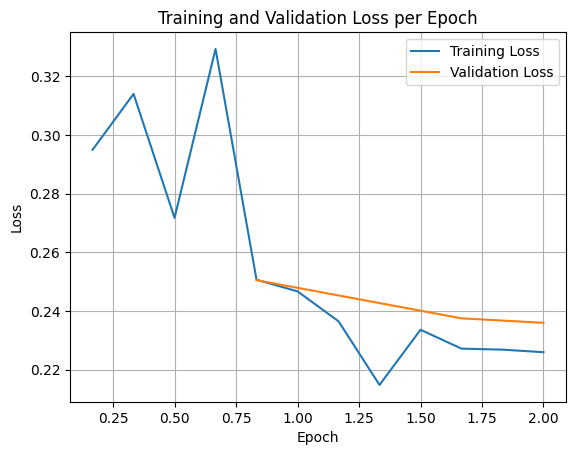

In [ ]:
log_history = trainer.state.log_history

# Extract training loss and the corresponding epoch numbers
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]

# Extract validation loss and the corresponding epoch numbers
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Plot both curves on the same axes
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
cleanup()

from transformers import BitsAndBytesConfig
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    config.base_model,
    quantization_config=quantization_config,
    device_map="auto",
    torch_dtype=torch.float16,
)

# 2. Gắn adapter LoRA từ thư mục checkpoint vào base model
model = PeftModel.from_pretrained(base_model, config.output_dir)

# 3. Tiến hành gộp phẳng (Merge and Unload)
merged_model = model.merge_and_unload()

# 4. Lưu mô hình đã merge
final_save_path = "./mistral_manim_merged"
merged_model.save_pretrained(final_save_path, safe_serialization=True)

tokenizer = AutoTokenizer.from_pretrained(config.base_model)
tokenizer.save_pretrained("./mistral_manim_merged")
print("Đã lưu tokenizer thành công!")

print(f"Đã merge và lưu mô hình thành công tại: {final_save_path}")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:373: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

NameError: name 'tokenizer' is not defined

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(config.base_model)
tokenizer.save_pretrained("./mistral_manim_merged")
print("Đã lưu tokenizer thành công!")

Đã lưu tokenizer thành công!


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

cleanup()

# 1. Load mô hình và tokenizer từ thư mục đã merge
model_path = "./mistral_manim_merged"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    device_map="auto",
    torch_dtype=torch.float16
)

tokenizer.chat_template = (
    "{{ bos_token }}"
    "{% for message in messages %}"
        "{% if message['role'] == 'system' %}"
            "{{ 'System: ' + message['content'] + '\n\n' }}"
        "{% elif message['role'] == 'user' %}"
            "{{ '[INST] ' + message['content'] + ' [/INST]' }}"
        "{% elif message['role'] == 'assistant' %}"
            "{{ ' ' + message['content'] + eos_token }}"
        "{% endif %}"
    "{% endfor %}"
)

def generate_manim_code(instruction):
    system_prompt = "Yor are an Coding Python Expert, read the instruction and complete these code correctly"
    user_content = instruction

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content}
    ]

    # Apply chat template
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # Tokenize input
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    # Sinh văn bản (Generation)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            temperature=0.2,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return decoded_output

test_instruction = "Create a square with side length 4 and color it red, then animate it to shift right by 3 units."
print(f"=== INSTRUCTION: {test_instruction} ===\n")
generated_code = generate_manim_code(test_instruction)
print(generated_code)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

=== INSTRUCTION: Create a square with side length 4 and color it red, then animate it to shift right by 3 units. ===

System: Yor are an Coding Python Expert, read the instruction and complete these code correctly

 Create a square with side length 4 and color it red, then animate it to shift right by 3 units.  from manim import * class MyScene(Scene): def construct(self): square = Square(side_length=4, color=RED) self.add(square) self.play(square.animate.shift(RIGHT * 3), run_time=3)


In [ ]:
from tqdm import tqdm
import ast

def is_syntax_valid(code_str):
    try:
        ast.parse(code_str)
        return True, ""
    except SyntaxError as e:
        return False, str(e)

valid_count = 0
total_samples = len(val_ds)

for i in tqdm(range(total_samples)):
    instruction = val_ds[i]["instruction"]
    generated_code = generate_manim_code(instruction)
    is_valid, err_msg = is_syntax_valid(generated_code)
    if is_valid:
        valid_count += 1

accuracy = (valid_count / total_samples) * 100
print(f"\nPython Right Syntax: {accuracy:.2f}% ({valid_count}/{total_samples})")

In [ ]:
from huggingface_hub import login
from google.colab import userdata

# your HF
hf_token = userdata.get('HF_TOKEN_WRITE')
login(token=hf_token)

# Push to HF Hub
merged_model.push_to_hub("TheSon2202/mistral-manim-python-coder-v01")
tokenizer.push_to_hub("TheSon2202/mistral-manim-python-coder-v01")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...x3tfnx_/model.safetensors:   0%|          | 30.0kB / 4.14GB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/TheSon2202/mistral-manim-python-coder-v01/commit/6c52a59b8bd4965c186638c32b1dc896e454bb4c', commit_message='Upload tokenizer', commit_description='', oid='6c52a59b8bd4965c186638c32b1dc896e454bb4c', pr_url=None, repo_url=RepoUrl('https://huggingface.co/TheSon2202/mistral-manim-python-coder-v01', endpoint='https://huggingface.co', repo_type='model', repo_id='TheSon2202/mistral-manim-python-coder-v01'), pr_revision=None, pr_num=None)

#### Optuna

In [ ]:
#Tuner Hyperparameter with Optuna